# Machine Learning & Deep Learning: CI7521
## Coursework 2

# Table of Contents

1. [Load Modules](#Load-modules-(code))
2. [Load Data](#Load-data)
3. [Initial Visualisation](#Initial-Visualisation)
4. [Q1: Baseline Neural Network](#Q1) (1 hidden layer, 100 neurons)
5. [Q2: Improved Neural Network](#Q2) (5 trials, hyperparameter exploration)
6. [Q3: Baseline CNN](#Q3) (1 convolutional block)
7. [Q4: Improved CNN](#Q4) (5 trials, hyperparameter exploration)
8. [Q5: Transfer Learning](#Q5) (DenseNet121, VGG16)
9. [Q6: Test Set Evaluation](#Q6) (comparative study of all 6 models)
10. [Q7: Data Augmentation](#Q7) (addressing class imbalance)
11. [References](#References-(text))

# Group number: **11**

| Sl.no | Name                         | KU-ID's |
|------:|------------------------------|---------|
| 1.    | Lalith Aditya Devaraj        | K2551111 |
| 2.    | Raja Mathangi Sundar         | K2542487 |
| 3.    | Shalini Manikkavasagam       | K2551032 |
| 4.    | Threya Reddy Tummeti         | K2557789 |

# Load modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import VGG16, DenseNet121
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)

# Load data

In [2]:
data = np.load('organsmnist_128.npz')
x_train = data['train_images'].astype('float32') / 255.0
x_val   = data['val_images'].astype('float32') / 255.0
x_test  = data['test_images'].astype('float32') / 255.0
y_train = data['train_labels'].flatten()
y_val   = data['val_labels'].flatten()
y_test  = data['test_labels'].flatten()
del data  # free memory

# channel dimension: (N, 128, 128) -> (N, 128, 128, 1)
x_train = x_train[..., np.newaxis]
x_val   = x_val[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

CLASS_NAMES = ['Bladder', 'Femur-L', 'Femur-R', 'Heart', 'Kidney-L',
               'Kidney-R', 'Liver', 'Lung-L', 'Lung-R', 'Pancreas', 'Spleen']
NUM_CLASSES = len(CLASS_NAMES)

print(f'Training set:   {x_train.shape}  Labels: {y_train.shape}')
print(f'Validation set: {x_val.shape}  Labels: {y_val.shape}')
print(f'Test set:       {x_test.shape}  Labels: {y_test.shape}')
print(f'Classes: {NUM_CLASSES}  |  Pixel range: [{x_train.min():.1f}, {x_train.max():.1f}]')

Training set:   (13932, 128, 128, 1)  Labels: (13932,)
Validation set: (2452, 128, 128, 1)  Labels: (2452,)
Test set:       (8827, 128, 128, 1)  Labels: (8827,)
Classes: 11  |  Pixel range: [0.0, 1.0]


### Dataset

**OrganSMNIST** is part of the MedMNIST v2 benchmark [1]. These are 2D slices extracted from 3D abdominal CT volumes in the Liver Tumor Segmentation Benchmark (LiTS) [7].

**Data preparation applied:**
- **Normalisation**: Pixel values scaled from [0, 255] to [0.0, 1.0], helps with gradient stability and convergence
- **Channel dimension**: Expanded from (128, 128) to (128, 128, 1) since Keras Conv2D layers expect a channel axis

# Initial Visualisation

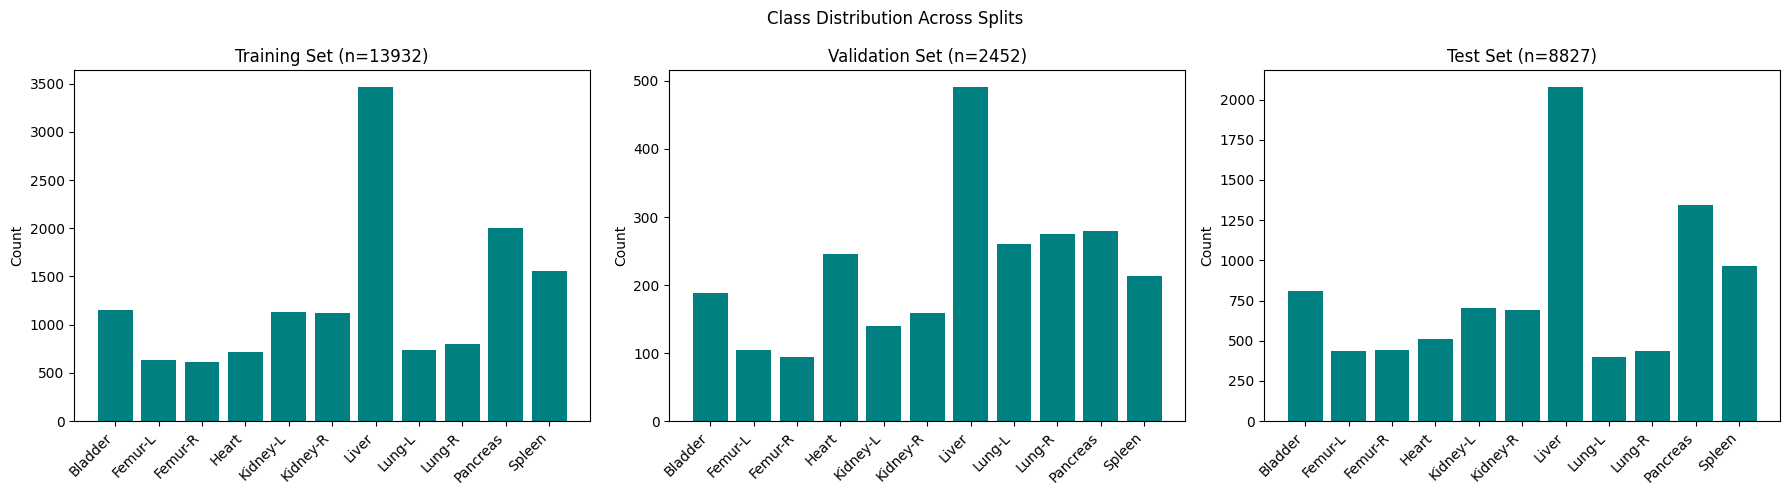

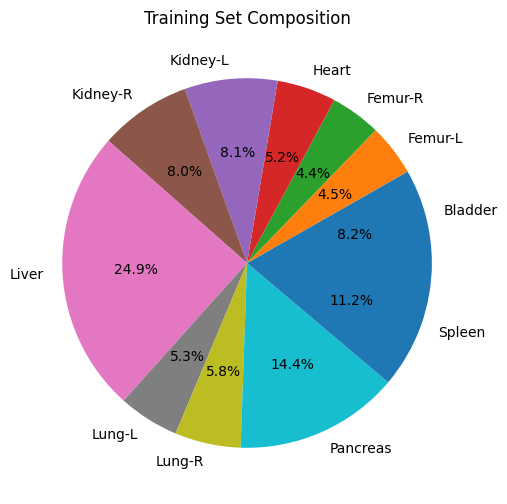

In [3]:
# Class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (labels, title) in zip(axes, [(y_train, 'Training'), (y_val, 'Validation'), (y_test, 'Test')]):
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    ax.bar(range(NUM_CLASSES), counts, color='teal')
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_title(f'{title} Set (n={len(labels)})')
    ax.set_ylabel('Count')
plt.suptitle('Class Distribution Across Splits')
plt.tight_layout(); plt.show()

counts = [np.sum(y_train == i) for i in range(NUM_CLASSES)]
plt.figure(figsize=(6,6))
plt.pie(counts, labels=CLASS_NAMES, autopct='%1.1f%%')
plt.title('Training Set Composition')
plt.show()


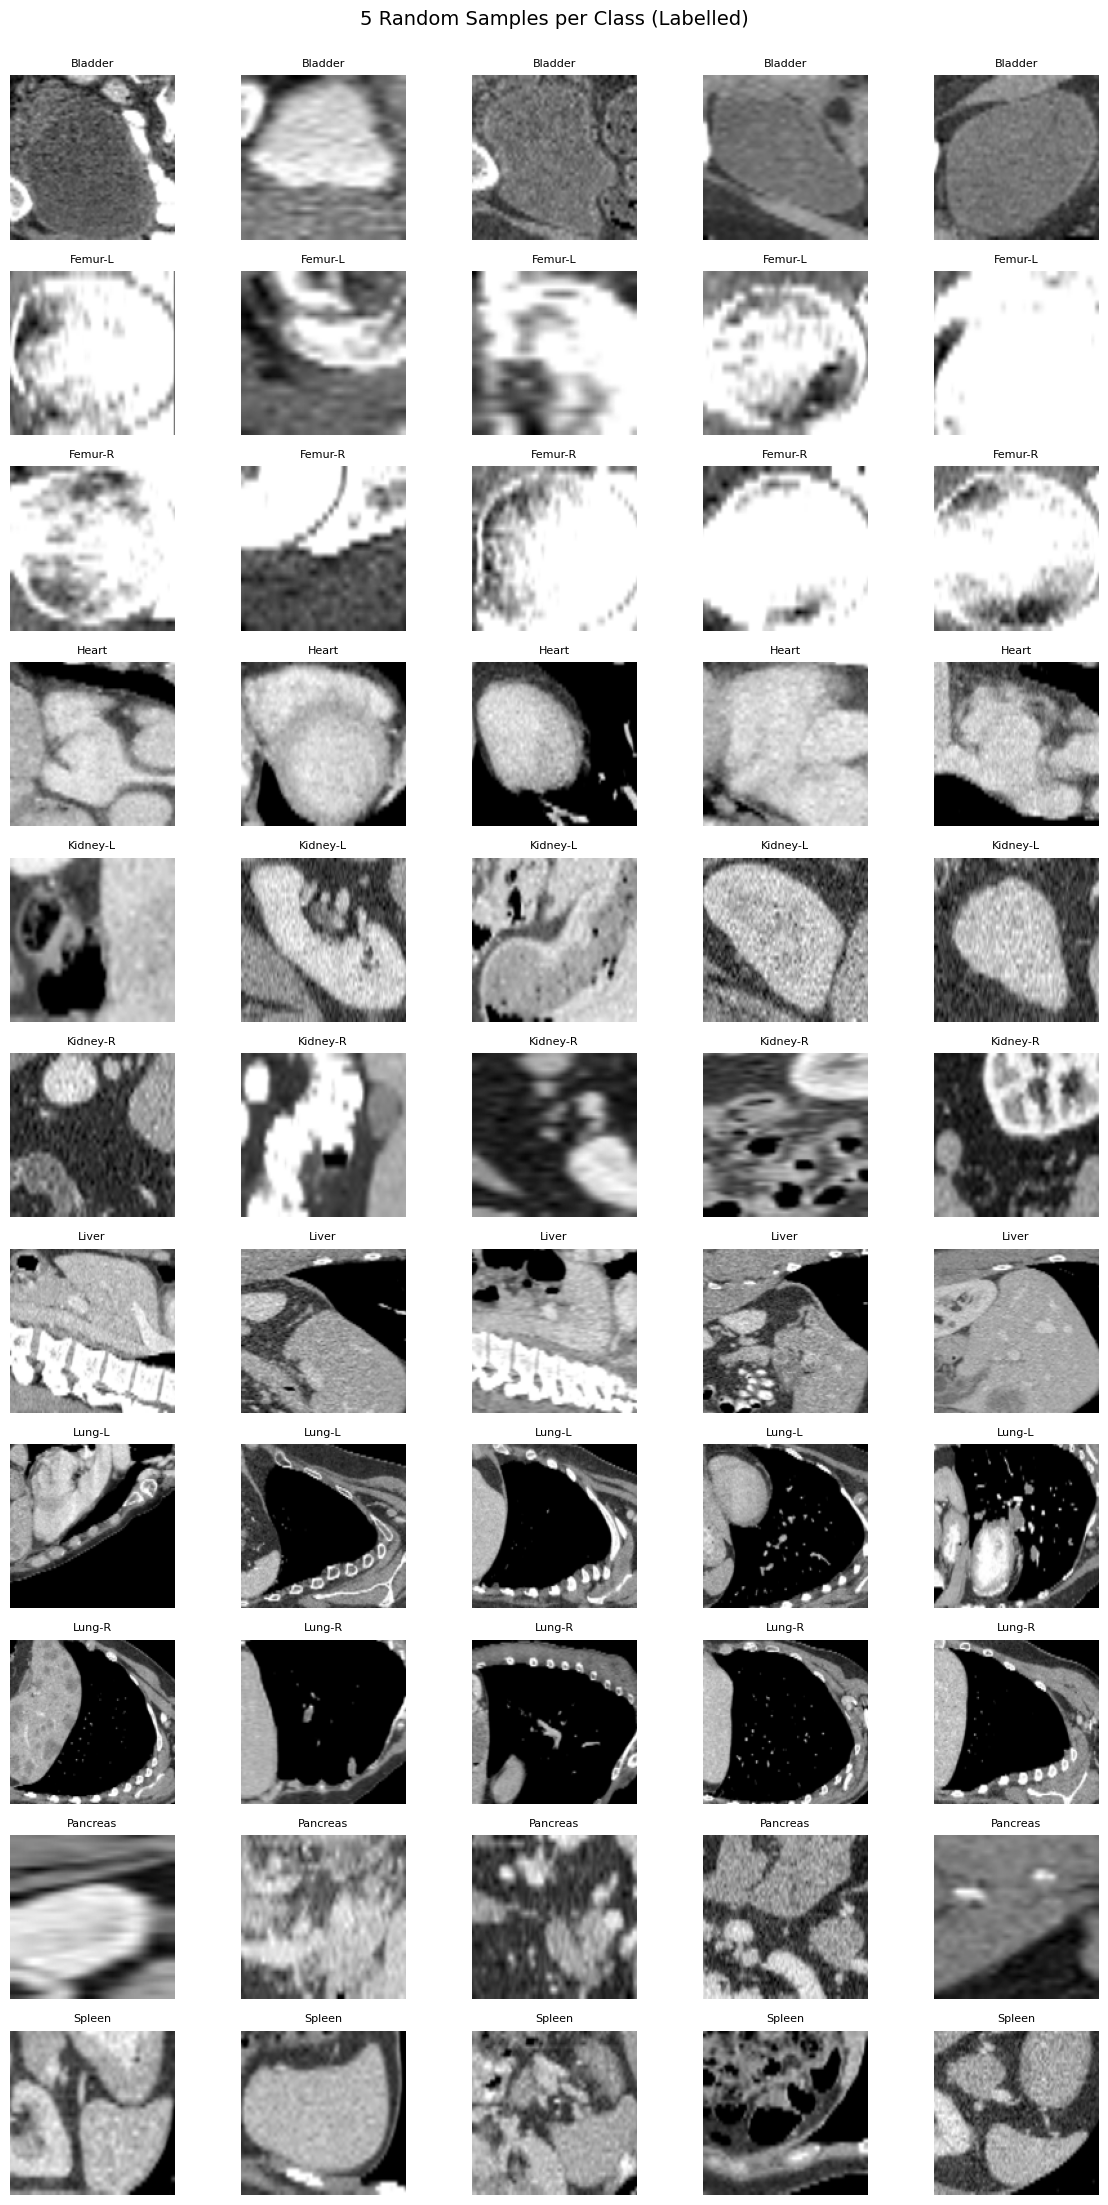

In [4]:
# Random samples per class (labelled)
np.random.seed(0)
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(12, 22))
for i in range(NUM_CLASSES):
    indices = np.where(y_train == i)[0]
    samples = np.random.choice(indices, 5, replace=False)
    for j, idx in enumerate(samples):
        axes[i, j].imshow(x_train[idx, :, :, 0], cmap='gray')
        axes[i, j].set_title(CLASS_NAMES[i], fontsize=8)
        axes[i, j].axis('off')
plt.suptitle('5 Random Samples per Class (Labelled)', fontsize=14, y=1.0)
plt.tight_layout(); plt.show()

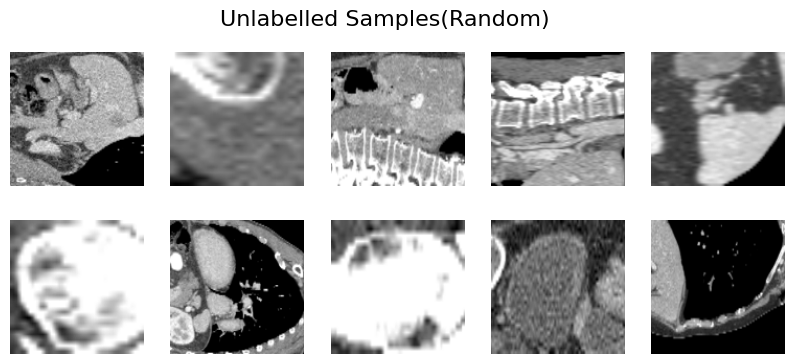

In [5]:
# Unlabelled Random Image Grid
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[np.random.randint(len(x_train)), :, :, 0], cmap='gray')
    plt.axis('off')
plt.suptitle('Unlabelled Samples(Random)', fontsize=16)
plt.show()

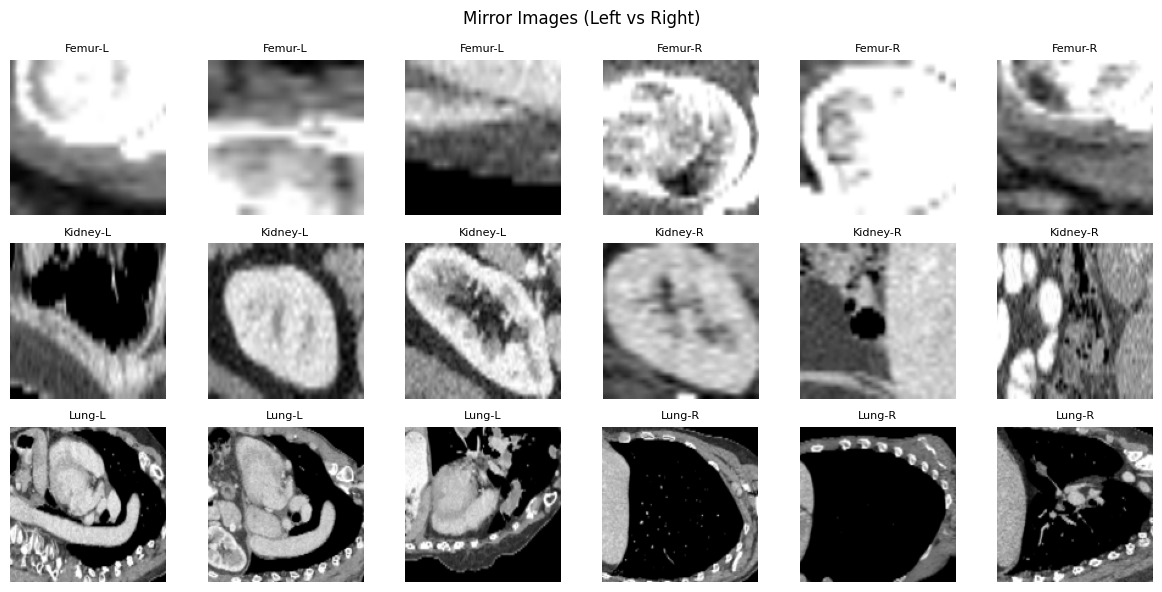

In [6]:
# Mirror Pairs (L vs R)
pairs = [('Femur-L','Femur-R'), ('Kidney-L','Kidney-R'), ('Lung-L','Lung-R')]
plt.figure(figsize=(12,6))
for r, (ln, rn) in enumerate(pairs):
    li, ri = np.where(y_train==CLASS_NAMES.index(ln))[0], np.where(y_train==CLASS_NAMES.index(rn))[0]
    for c in range(3):
        plt.subplot(3,6,r*6+c+1), plt.imshow(x_train[li[c],...,0], 'gray'), plt.title(ln, fontsize=8), plt.axis('off')
        plt.subplot(3,6,r*6+c+4), plt.imshow(x_train[ri[c],...,0], 'gray'), plt.title(rn, fontsize=8), plt.axis('off')
plt.suptitle('Mirror Images (Left vs Right)')
plt.tight_layout(); plt.show()

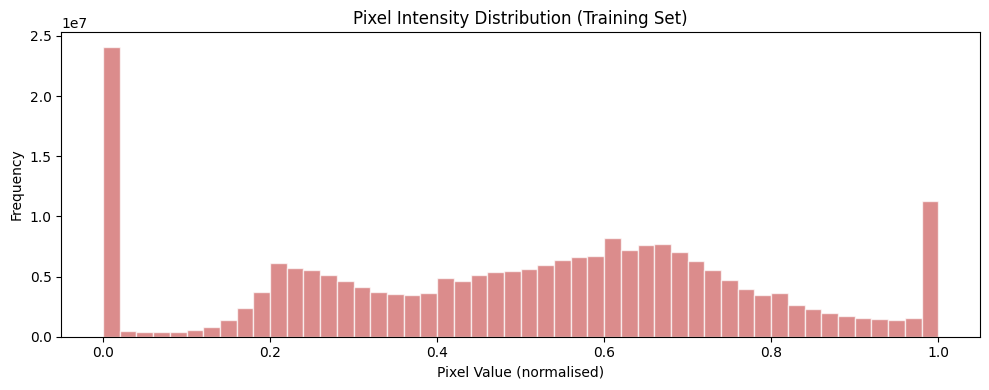

In [7]:
# Pixel intensity distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(x_train.flatten(), bins=50, color='indianred', alpha=0.7, edgecolor='white')
ax.set_title('Pixel Intensity Distribution (Training Set)')
ax.set_xlabel('Pixel Value (normalised)'); ax.set_ylabel('Frequency')
plt.tight_layout(); plt.show()


**Observations:**

- The dataset contains **11 classes** of abdominal organ CT scans at 128×128 resolution in grayscale. These are 2D slices from 3D CT volumes, sourced from the Liver TumorSegmentation Benchmark (LiTS) dataset [7]..

- Looking at the bar charts, there is a clear **class imbalance**. The Liver class alone makes up
  about 24.9% of the training data (3,464 images), while the Femur-R class has only 4.4% (614 images).
  That is roughly a **5.6x difference** between the largest and smallest class. This means models
  could learn to just predict “Liver” more often since they see it so much more.

- The labelled sample grid shows that organs have visually distinct shapes the liver is large and
  rounded, the femurs are elongated, and the heart has a recognisable oval shape. However, some pairs
  look very similar: **left/right variants** of the same organ (kidney-L vs kidney-R, femur-L vs
  femur-R, lung-L vs lung-R) are nearly mirror images.

- The **pixel intensity histogram** is heavily skewed toward 0 (black), with most pixel values
  sitting below 0.2. This is typical for CT scans the background and air regions are dark, and
  only the organ tissue shows brighter values. This means our models will mostly be working with
  subtle differences in the lower intensity range.

## Q1


### Baseline Neural Network: One hidden layer, 100 neurons

A fully connected network that flattens each 128×128 image into a vector
of 16,384 pixels and passes it through a single hidden layer of 100 neurons.

In [8]:
model_q1 = keras.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Flatten(),
    layers.Dense(100, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='Q1_Baseline_NN')

model_q1.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
model_q1.summary()

Model: "Q1_Baseline_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     1,638,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         1,111 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,639,611 (6.25 MB)

 Trainable params: 1,639,611 (6.25 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_q1 = model_q1.fit(x_train, y_train,
                           validation_data=(x_val, y_val),
                           epochs=20, batch_size=128,
                           callbacks=[early_stop], verbose=1)

model_q1.save('model_q1.keras')
q1_val_acc = max(history_q1.history['val_accuracy'])
print(f'\nBest validation accuracy: {q1_val_acc:.4f}')

Epoch 1/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3273 - loss: 2.4605 - val_accuracy: 0.4343 - val_loss: 1.5043
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4345 - loss: 1.5861 - val_accuracy: 0.4910 - val_loss: 1.3557
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4677 - loss: 1.4805 - val_accuracy: 0.5024 - val_loss: 1.2795
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4908 - loss: 1.4195 - val_accuracy: 0.5351 - val_loss: 1.2191
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5115 - loss: 1.3720 - val_accuracy: 0.5701 - val_loss: 1.1732
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5260 - loss: 1.3260 - val_accuracy: 0.5816 - val_loss: 1.1402
Epoch 7/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5405 - loss: 1.2831 - val_accuracy: 0.5889 - val_loss: 1.1158
Epoch 8/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5574 - loss: 1.2430 - val_accuracy: 0.

**Results:**

The baseline NN reached a **best validation accuracy of 64.44%** after training for 20 epochs.
Early stopping restored the best weights from around epoch 15, where validation loss was lowest.
The training and validation accuracies ended up fairly close (around 60–62%), confirming
the model has **not started overfitting**, it simply lacks the capacity to learn more.

It is clear that a single hidden layer with 100 neurons is too limited.
It flattens the 128×128 image into 16,384 raw pixels and tries to classify from that, There's no
understanding of shapes, edges, or spatial layout. As a result, its performance sets a low baseline for Q2 to improve on.

## Q2

### Improved Neural Network: Hyperparameter Exploration

Improving the baseline by varying three key factors:

| Factor | Why it matters |
|---|---|
| **Network depth & width** | More layers and neurons give the model more capacity to learn complex patterns from raw pixels |
| **Dropout** | With 16,384 input features and ~14,000 training images, overfitting is a real risk. Dropout randomly disables neurons during training to build robustness |
| **Batch normalisation** | Stabilises training by normalising activations between layers, helping deeper networks converge faster |

In [10]:
trials_q2 = [
    {'name': 'Trial 1', 'hidden': [256, 128],       'dropout': 0.0, 'bn': False, 'lr': 0.001},
    {'name': 'Trial 2', 'hidden': [512, 256, 128],  'dropout': 0.3, 'bn': True,  'lr': 0.0005},
    {'name': 'Trial 3', 'hidden': [512, 256, 128],  'dropout': 0.4, 'bn': True,  'lr': 0.0005},
    {'name': 'Trial 4', 'hidden': [256, 128, 64],   'dropout': 0.3, 'bn': True,  'lr': 0.001},
    {'name': 'Trial 5', 'hidden': [1024, 512, 256], 'dropout': 0.4, 'bn': True,  'lr': 0.0003},
]

results_q2, histories_q2, models_q2 = [], [], []

for t in trials_q2:
    print(f"\n{'='*60}")
    print(f"{t['name']}: layers={t['hidden']}, dropout={t['dropout']}, BN={t['bn']}, lr={t['lr']}")
    print('='*60)

    model = keras.Sequential()
    model.add(layers.Input(shape=(128, 128, 1)))
    model.add(layers.Flatten())
    for units in t['hidden']:
        model.add(layers.Dense(units, activation='relu'))
        if t['bn']:
            model.add(layers.BatchNormalization())
        if t['dropout'] > 0:
            model.add(layers.Dropout(t['dropout']))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=t['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(x_train, y_train, validation_data=(x_val, y_val),
                        epochs=30, batch_size=128, callbacks=[es], verbose=1)
    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    results_q2.append({
        'Trial': t['name'], 'Layers': str(t['hidden']),
        'Dropout': t['dropout'], 'BN': t['bn'], 'LR': t['lr'],
        'Train Acc': round(history.history['accuracy'][-1], 4),
        'Val Acc': round(val_acc, 4), 'Val Loss': round(val_loss, 4),
        'Epochs': len(history.history['loss'])
    })
    histories_q2.append(history)
    models_q2.append(model)

df_q2 = pd.DataFrame(results_q2)
best_q2_idx = df_q2['Val Acc'].idxmax()
best_model_q2 = models_q2[best_q2_idx]
best_q2_config = trials_q2[best_q2_idx]
print(f'\nAll 5 trials complete!')


Trial 1: layers=[256, 128], dropout=0.0, BN=False, lr=0.001
Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.3479 - loss: 2.5602 - val_accuracy: 0.5175 - val_loss: 1.5332
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4698 - loss: 1.5177 - val_accuracy: 0.5763 - val_loss: 1.3696
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5095 - loss: 1.4092 - val_accuracy: 0.5914 - val_loss: 1.1805
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5444 - loss: 1.3027 - val_accuracy: 0.5893 - val_loss: 1.1341
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5665 - loss: 1.2314 - val_accuracy: 0.6415 - val_loss: 1.0360
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6050 - loss: 1.1147 - val_accuracy: 0.6737 - val_loss: 0.9932
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6316 - loss: 1.0499 - val_accuracy: 0.6786 - val_loss: 0.9191
Epoch 8/30
109/109 ━━━━━━━━━━━━━━━━━

In [11]:
print('\nQ2 \u2014 Neural Network Trials Summary')
print('=' * 90)
print(df_q2.to_string(index=False))
print(f"\nBest: {trials_q2[best_q2_idx]['name']}  |  Val Acc: {df_q2['Val Acc'].max():.4f}")


Q2 — Neural Network Trials Summary
  Trial           Layers  Dropout    BN     LR  Train Acc  Val Acc  Val Loss  Epochs
Trial 1       [256, 128]      0.0 False 0.0010     0.7211   0.6831    0.8837      13
Trial 2  [512, 256, 128]      0.3  True 0.0005     0.7295   0.7537    0.6901      20
Trial 3  [512, 256, 128]      0.4  True 0.0005     0.6857   0.7296    0.7072      21
Trial 4   [256, 128, 64]      0.3  True 0.0010     0.7008   0.7011    0.7812      18
Trial 5 [1024, 512, 256]      0.4  True 0.0003     0.6881   0.6778    0.8391      11

Best: Trial 2  |  Val Acc: 0.7537


In [12]:
best_model_q2.save('model_q2.keras')
q2_val_acc = df_q2['Val Acc'].max()

print('Best Q2 model architecture:')
best_model_q2.summary()
print(f'\nQ1 Baseline Val Acc: {q1_val_acc:.4f}')
print(f'Q2 Best Val Acc:     {q2_val_acc:.4f}')
print(f'Improvement:         +{q2_val_acc - q1_val_acc:.4f}')


Best Q2 model architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,671,459 (97.93 MB)

 Trainable params: 8,556,555 (32.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

 Optimizer params: 17,113,112 (65.28 MB)


Q1 Baseline Val Acc: 0.6448
Q2 Best Val Acc:     0.7537
Improvement:         +0.1089


### Discussion: Improved Neural Network

Looking at the summary table and training curves, here is what we found across our five trials:

**Hyperparameters**

We designed each trial to isolate the effect of a different factor:

- **Trial 1** (256, 128) is the simplest upgrade from Q1, just adding more neurons and a second
  layer, with no regularisation. This tests whether raw capacity alone helps.
- **Trial 2** (512, 256, 128) adds a third layer with dropout (0.3) and batch normalisation.
  More depth lets the model learn more abstract representations, while Batch Normalization + dropout control overfitting.
- **Trial 3** (512, 256, 128) is the same architecture as Trial 2 but with stronger dropout (0.4),
  testing whether heavier regularisation pays off.
- **Trial 4** (256, 128, 64) tests a narrower 3-layer variant with Batch Normalization, fewer parameters but
  still deep.
- **Trial 5** (1024, 512, 256) pushes capacity to the maximum with heavy regularisation and a very
  low learning rate (0.0003), testing whether raw model size matters.

**Key results from the table:**

- **Trial 2** achieved the highest validation accuracy (75.4%). Its deeper architecture (512→256→128), combined with batch normalisation and moderate dropout (0.3), provided a strong balance between learning capacity and regularisation. The slightly lower learning rate (0.0005) likely helped the model converge more smoothly.
- **Trial 3** performed slightly worse than Trial 2 despite having the same architecture. The higher dropout (0.4) may have introduced too much regularisation, slightly limiting performance.
- **Trial 4** (70.1%) shows that a smaller architecture (256→128→64) with batch normalisation can still perform reasonably well, though it lacks the capacity of deeper models.
- **Trial 1** (68.3%), which had no regularisation (no BN, no dropout), performed worse than the regularised models, indicating mild overfitting.
- **Trial 5** (67.8%), despite being the largest model, underperformed. Its very low learning rate (0.0003) combined with stronger dropout likely slowed convergence and prevented the model from fully learning.

## Q3


### Baseline CNN: One Convolutional Block

In [13]:
model_q3 = keras.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='Q3_Baseline_CNN')

model_q3.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
model_q3.summary()

Model: "Q3_Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,147 (12.29 KB)

 Trainable params: 3,147 (12.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_q3 = model_q3.fit(x_train, y_train,
                           validation_data=(x_val, y_val),
                           epochs=20, batch_size=32,
                           callbacks=[es], verbose=1)

model_q3.save('model_q3.keras')
q3_val_acc = max(history_q3.history['val_accuracy'])
print(f'\nBest validation accuracy: {q3_val_acc:.4f}')

Epoch 1/20
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.2775 - loss: 2.0744 - val_accuracy: 0.3308 - val_loss: 1.7827
Epoch 2/20
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3536 - loss: 1.7849 - val_accuracy: 0.3630 - val_loss: 1.6367
Epoch 3/20
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.4101 - loss: 1.6427 - val_accuracy: 0.4074 - val_loss: 1.5484
Epoch 4/20
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.4346 - loss: 1.5353 - val_accuracy: 0.4246 - val_loss: 1.4740
Epoch 5/20
436/436 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.4448 - loss: 1.4651 - val_accuracy: 0.4290 - val_loss: 1.4083
Epoch 6/20
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.4556 - loss: 1.4077 - val_accuracy: 0.4356 - val_loss: 1.3540
Epoch 7/20
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.4686 - loss: 1.3563 - val_accuracy: 0.4400 - val_loss: 1.3029
Epoch 8/20
436/436 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.4824 - loss: 1.3105 - 

**Results:**

The baseline CNN reached a **validation accuracy of about 61.9%** after running all 20 epochs
(early stopping was never triggered). Training accuracy was similar, meaning the model had not
started to overfit, it was still under-learning.

One convolutional block with just 32 filters is very limited.
It detects low-level features like edges and brightness gradients, but with only one Conv2D layer
it has no way to combine them into higher-level patterns like organ shapes. The NN’s advantage here
is that it has a direct connection from every pixel to 100 hidden neurons, giving it more raw
capacity despite no spatial awareness.

The takeaway is clear: one convolutional block is not enough for this task. The model needs more
depth to learn the kind of hierarchical features (edges → textures → shapes → organs) that
distinguish 11 different classes. Q4 will address this by stacking multiple convolutional blocks.

## Q4

### Improved CNN: Hyperparameter Exploration

Building on the single-block baseline, we now explore deeper CNN architectures by varying:

| Factor | What we test |
|---|---|
| **Number of conv blocks** | 2 to 4 blocks for progressively deeper feature hierarchies |
| **Dropout** | 0.0 to 0.4 to control overfitting |
| **Batch normalisation** | Stabilises gradients in deeper networks |
| **Learning rate** | 0.001 vs 0.0005 for finer optimisation |

In [15]:
trials_q4 = [
    {'name': 'Trial 1', 'filters': [32, 64, 128],      'dropout': 0.2,  'bn': False, 'lr': 0.001},
    {'name': 'Trial 2', 'filters': [32, 64, 128],      'dropout': 0.25, 'bn': False, 'lr': 0.001},
    {'name': 'Trial 3', 'filters': [32, 64, 128],      'dropout': 0.4,  'bn': True,  'lr': 0.0005},
    {'name': 'Trial 4', 'filters': [64, 128, 256],     'dropout': 0.3,  'bn': True,  'lr': 0.001},
    {'name': 'Trial 5', 'filters': [32, 64, 128, 256], 'dropout': 0.3,  'bn': True,  'lr': 0.0005},
]

results_q4, histories_q4, models_q4 = [], [], []

for t in trials_q4:
    print(f"\n{'='*60}")
    print(f"{t['name']}: filters={t['filters']}, dropout={t['dropout']}, BN={t['bn']}, lr={t['lr']}")
    print('='*60)

    model = keras.Sequential()
    model.add(layers.Input(shape=(128, 128, 1)))
    for f in t['filters']:
        model.add(layers.Conv2D(f, (3, 3), activation='relu', padding='same'))
        if t['bn']:
            model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))
        if t['dropout'] > 0:
            model.add(layers.Dropout(t['dropout']))
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(128, activation='relu'))
    if t['dropout'] > 0:
        model.add(layers.Dropout(t['dropout']))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=t['lr']),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    es = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(x_train, y_train, validation_data=(x_val, y_val),
                        epochs=25, batch_size=32, callbacks=[es], verbose=1)
    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    results_q4.append({
        'Trial': t['name'], 'Filters': str(t['filters']),
        'Dropout': t['dropout'], 'BN': t['bn'], 'LR': t['lr'],
        'Train Acc': round(history.history['accuracy'][-1], 4),
        'Val Acc': round(val_acc, 4), 'Val Loss': round(val_loss, 4),
        'Epochs': len(history.history['loss'])
    })
    histories_q4.append(history)
    models_q4.append(model)

df_q4 = pd.DataFrame(results_q4)
best_q4_idx = df_q4['Val Acc'].idxmax()
best_model_q4 = models_q4[best_q4_idx]
best_q4_config = trials_q4[best_q4_idx]
print(f'\nAll 5 trials complete!')


Trial 1: filters=[32, 64, 128], dropout=0.2, BN=False, lr=0.001
Epoch 1/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 35s 78ms/step - accuracy: 0.4063 - loss: 1.6377 - val_accuracy: 0.4666 - val_loss: 1.3518
Epoch 2/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - accuracy: 0.4984 - loss: 1.2605 - val_accuracy: 0.5192 - val_loss: 1.0660
Epoch 3/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 33s 77ms/step - accuracy: 0.5548 - loss: 1.0990 - val_accuracy: 0.6464 - val_loss: 0.8798
Epoch 4/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 34s 77ms/step - accuracy: 0.6172 - loss: 0.9524 - val_accuracy: 0.6713 - val_loss: 0.7582
Epoch 5/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - accuracy: 0.6586 - loss: 0.8367 - val_accuracy: 0.7292 - val_loss: 0.6482
Epoch 6/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 33s 76ms/step - accuracy: 0.6798 - loss: 0.7735 - val_accuracy: 0.7463 - val_loss: 0.6518
Epoch 7/25
436/436 ━━━━━━━━━━━━━━━━━━━━ 34s 77ms/step - accuracy: 0.6928 - loss: 0.7225 - val_accuracy: 0.7516 - val_loss: 0.5981
Epoch 8/25
436/436 ━━━━━━

In [16]:
print('\nQ4 \u2014 CNN Trials Summary')
print('=' * 90)
print(df_q4.to_string(index=False))
print(f"\nBest: {trials_q4[best_q4_idx]['name']}  |  Val Acc: {df_q4['Val Acc'].max():.4f}")



Q4 — CNN Trials Summary
  Trial            Filters  Dropout    BN     LR  Train Acc  Val Acc  Val Loss  Epochs
Trial 1      [32, 64, 128]     0.20 False 0.0010     0.8101   0.8532    0.3681      25
Trial 2      [32, 64, 128]     0.25 False 0.0010     0.8019   0.8654    0.3310      25
Trial 3      [32, 64, 128]     0.40  True 0.0005     0.8536   0.8556    0.3292      17
Trial 4     [64, 128, 256]     0.30  True 0.0010     0.9310   0.8740    0.3811      23
Trial 5 [32, 64, 128, 256]     0.30  True 0.0005     0.9087   0.8719    0.3054      13

Best: Trial 4  |  Val Acc: 0.8740


In [17]:
best_model_q4.save('model_q4.keras')
q4_val_acc = df_q4['Val Acc'].max()

print('Best Q4 model architecture:')
best_model_q4.summary()
print(f'\nQ3 Baseline Val Acc: {q3_val_acc:.4f}')
print(f'Q4 Best Val Acc:     {q4_val_acc:.4f}')
print(f'Improvement:         +{q4_val_acc - q3_val_acc:.4f}')


Best Q4 model architecture:


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,215,523 (4.64 MB)

 Trainable params: 404,875 (1.54 MB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 809,752 (3.09 MB)


Q3 Baseline Val Acc: 0.6195
Q4 Best Val Acc:     0.8740
Improvement:         +0.2545


### Discussion: Improved CNN

Five CNN trials progressively build on the Q3 baseline by adding depth, regularisation,
and architectural refinements.

**Hyperparameters:**

- **Trials 1–2** (3 blocks, [32,64,128]) test adding two more conv blocks to the Q3 baseline.
  With three blocks and MaxPooling, spatial dimensions reduce from 128×128 down to 16×16, giving
  a good balance between spatial detail and abstraction. We test dropout at 0.2 and 0.25.
- **Trial 3** (3 blocks, [32,64,128]) adds batch normalisation and higher dropout (0.4) with a
  lower learning rate, testing whether stronger regularisation helps.
- **Trial 4** uses wider filters (64, 128, 256) to increase the feature capacity at each level
  with BN and dropout.
- **Trial 5** adds a fourth block (32, 64, 128, 256), testing whether an even deeper hierarchy helps.

**Key results from the table:**

- **Trial 4** achieved the best performance with a validation accuracy of 87.4%, demonstrating that increasing filter depth (64→128→256) combined with batch normalisation and moderate dropout (0.3) provides the best balance between learning capacity and generalisation.
- **Trials 1 and 2** (85.3%–86.5%) show that simply stacking convolutional layers already leads to a large performance jump compared to Q3, suggesting that increasing depth improves CNN performance improvements.
- **Trial 5** (87.2%) did not outperform Trial 4 despite being deeper. This suggests that additional depth alone does not guarantee better performance, and may require longer training or more careful optimisation to fully converge.
- **Trial 3** (85.6%) shows that excessive regularisation (dropout 0.4 with batch normalisation) can slightly reduce performance by limiting feature learning capacity.

## Q5

### Transfer Learning: Pretrained CNN Architectures

Transfer learning lets us reuse features learned from millions of ImageNet images.

**Two** established architectures for transfer learning were chosen:

| Architecture | Key idea | Why we chose it |
|---|---|---|
| **DenseNet121** | Dense connections for feature reuse (2017) [4] | Parameter efficient, every layer receives inputs from all preceding layers, encouraging feature reuse. This makes it effective even with frozen weights, since information flows freely across the network |
| **VGG16** | Simple stacked 3×3 convolutions (2014) [3] | Reliable and well validated in medical imaging literature. Its straightforward architecture produces clean, well separated feature maps |

Since the images are grayscale (1 channel) but pretrained models expect RGB (3 channels), we
replicate the single channel three times.

**Setup:** Frozen pretrained base, Global Average Pooling, Dense(256), Dropout(0.3), Softmax(11)

We use **feature extraction only** (frozen base weights) rather than fine-tuning because our
dataset is relatively small (~14k images) and fine tuning risks overfitting. The frozen ImageNet
features already provide powerful low level representations.

In [18]:
# DenseNet121
print(f"\n{'='*60}")
print('Training DenseNet121 (frozen base)')
print('='*60)

inputs_5a = layers.Input(shape=(128, 128, 1))
x = layers.Concatenate()([inputs_5a, inputs_5a, inputs_5a])  # grayscale -> 3-channel
base_5a = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_5a.trainable = False
x = base_5a(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out_5a = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_5a = keras.Model(inputs_5a, out_5a, name='DenseNet121')
model_5a.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
hist_5a = model_5a.fit(x_train, y_train, validation_data=(x_val, y_val),
                       epochs=15, batch_size=32, callbacks=[es], verbose=1)
loss_5a, acc_5a = model_5a.evaluate(x_val, y_val, verbose=0)


# VGG16
print(f"\n{'='*60}")
print('Training VGG16')
print('='*60)

inputs_5b = layers.Input(shape=(128, 128, 1))
x = layers.Concatenate()([inputs_5b, inputs_5b, inputs_5b])
base_5b = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_5b.trainable = False
x = base_5b(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out_5b = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model_5b = keras.Model(inputs_5b, out_5b, name='VGG16')
model_5b.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])

es = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
hist_5b = model_5b.fit(x_train, y_train, validation_data=(x_val, y_val),
                       epochs=15, batch_size=32, callbacks=[es], verbose=1)
loss_5b, acc_5b = model_5b.evaluate(x_val, y_val, verbose=0)


# Collect results for summary
results_q5 = [
    {'Architecture': 'DenseNet121', 'Val Acc': round(acc_5a, 4),
     'Val Loss': round(loss_5a, 4), 'Epochs': len(hist_5a.history['loss'])},
    {'Architecture': 'VGG16', 'Val Acc': round(acc_5b, 4),
     'Val Loss': round(loss_5b, 4), 'Epochs': len(hist_5b.history['loss'])},
]
histories_q5 = [hist_5a, hist_5b]
models_q5 = {'DenseNet121': model_5a, 'VGG16': model_5b}
arch_names = ['DenseNet121', 'VGG16']

print('\nBoth transfer learning models trained!')


Training DenseNet121 (frozen base)
Epoch 1/15
436/436 ━━━━━━━━━━━━━━━━━━━━ 103s 221ms/step - accuracy: 0.7013 - loss: 0.8147 - val_accuracy: 0.8426 - val_loss: 0.3889
Epoch 2/15
436/436 ━━━━━━━━━━━━━━━━━━━━ 94s 216ms/step - accuracy: 0.8000 - loss: 0.4929 - val_accuracy: 0.8707 - val_loss: 0.3231
Epoch 3/15
436/436 ━━━━━━━━━━━━━━━━━━━━ 96s 220ms/step - accuracy: 0.8356 - loss: 0.4071 - val_accuracy: 0.8711 - val_loss: 0.3175
Epoch 4/15
436/436 ━━━━━━━━━━━━━━━━━━━━ 97s 223ms/step - accuracy: 0.8555 - loss: 0.3579 - val_accuracy: 0.8777 - val_loss: 0.3078
Epoch 5/15
436/436 ━━━━━━━━━━━━━━━━━━━━ 96s 220ms/step - accuracy: 0.8729 - loss: 0.3112 - val_accuracy: 0.8638 - val_loss: 0.3490
Epoch 6/15
436/436 ━━━━━━━━━━━━━━━━━━━━ 96s 219ms/step - accuracy: 0.8810 - loss: 0.2852 - val_accuracy: 0.8793 - val_loss: 0.3009
Epoch 7/15
436/436 ━━━━━━━━━━━━━━━━━━━━ 102s 233ms/step - accuracy: 0.8929 - loss: 0.2589 - val_accuracy: 0.8707 - val_loss: 0.3355
Epoch 8/15
436/436 ━━━━━━━━━━━━━━━━━━━━ 94s 2

In [19]:
df_q5 = pd.DataFrame(results_q5)
print('\nQ5 \u2014 Transfer Learning Summary')
print('=' * 60)
print(df_q5.to_string(index=False))

models_q5['DenseNet121'].save('model_q5a.keras')
models_q5['VGG16'].save('model_q5b.keras')


Q5 — Transfer Learning Summary
Architecture  Val Acc  Val Loss  Epochs
 DenseNet121   0.8793    0.3009       9
       VGG16   0.8597    0.3432       9


### Discussion: Transfer Learning

**Why DenseNet121 and VGG16:**

- **DenseNet121** [4] connects every layer to every other layer within each dense block. This
  "feature reuse" design means that even with frozen weights, the classifier on top receives a
  rich, diverse set of features from all depths of the network. This is especially useful in
  feature extraction mode where we cannot fine-tune individual layers.
- **VGG16** [3] is a classical CNN architecture built on stacked 3×3 convolutions. It provides stable and well-structured feature extraction and is often used as a baseline in transfer learning tasks, including medical imaging.

**Results from the summary table:**

Both architectures achieved strong validation accuracies, confirming that pretrained features
transfer well even to grayscale medical images at 128×128 resolution.

DenseNet121 achieved the best performance (87.93% validation accuracy), outperforming VGG16 (85.97%) by approximately 2%, indicating that its dense connectivity leads to more expressive feature reuse in this task.

## Q6

### Test Set Evaluation: Comparative Study of All 6 Models

We now evaluate the six best models (one from each question) on the **test set**. Data
never seen during training or validation.

In [40]:
# Load all 6 saved models from disk
model_q1 = keras.models.load_model('model_q1.keras')
model_q2 = keras.models.load_model('model_q2.keras')
model_q3 = keras.models.load_model('model_q3.keras')
model_q4 = keras.models.load_model('model_q4.keras')
model_q5a = keras.models.load_model('model_q5a.keras')
model_q5b = keras.models.load_model('model_q5b.keras')
print('All 6 models loaded from disk.')

model_names = [
    'Q1: Baseline NN', 'Q2: Improved NN',
    'Q3: Baseline CNN', 'Q4: Improved CNN',
    'Q5a: DenseNet121', 'Q5b: VGG16'
]
models_q6 = [model_q1, model_q2, model_q3, model_q4, model_q5a, model_q5b]

results_q6, predictions_q6 = [], []

for name, model in zip(model_names, models_q6):
    y_pred = model.predict(x_test, verbose=0).argmax(axis=1)
    predictions_q6.append(y_pred)
    results_q6.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1 (macro)': round(f1_score(y_test, y_pred, average='macro'), 4),
        'Precision': round(precision_score(y_test, y_pred, average='macro'), 4),
        'Recall': round(recall_score(y_test, y_pred, average='macro'), 4),
    })

df_q6 = pd.DataFrame(results_q6)
print('\nTest Set Performance \u2014 All 6 Models')
print('=' * 80)
print(df_q6.to_string(index=False))

best_idx = df_q6['F1 (macro)'].idxmax()
print(f"\nBest model: {model_names[best_idx]} (F1 macro: {df_q6.loc[best_idx, 'F1 (macro)']:.4f})")


All 6 models loaded from disk.

Test Set Performance — All 6 Models
           Model  Accuracy  F1 (macro)  Precision  Recall
 Q1: Baseline NN    0.4830      0.4312     0.4688  0.4389
 Q2: Improved NN    0.5329      0.5027     0.5157  0.5228
Q3: Baseline CNN    0.5532      0.4286     0.4953  0.4430
Q4: Improved CNN    0.7554      0.6864     0.7160  0.7053
Q5a: DenseNet121    0.7529      0.7037     0.7112  0.7061
      Q5b: VGG16    0.7358      0.6727     0.7083  0.6772

Best model: Q5a: DenseNet121 (F1 macro: 0.7037)


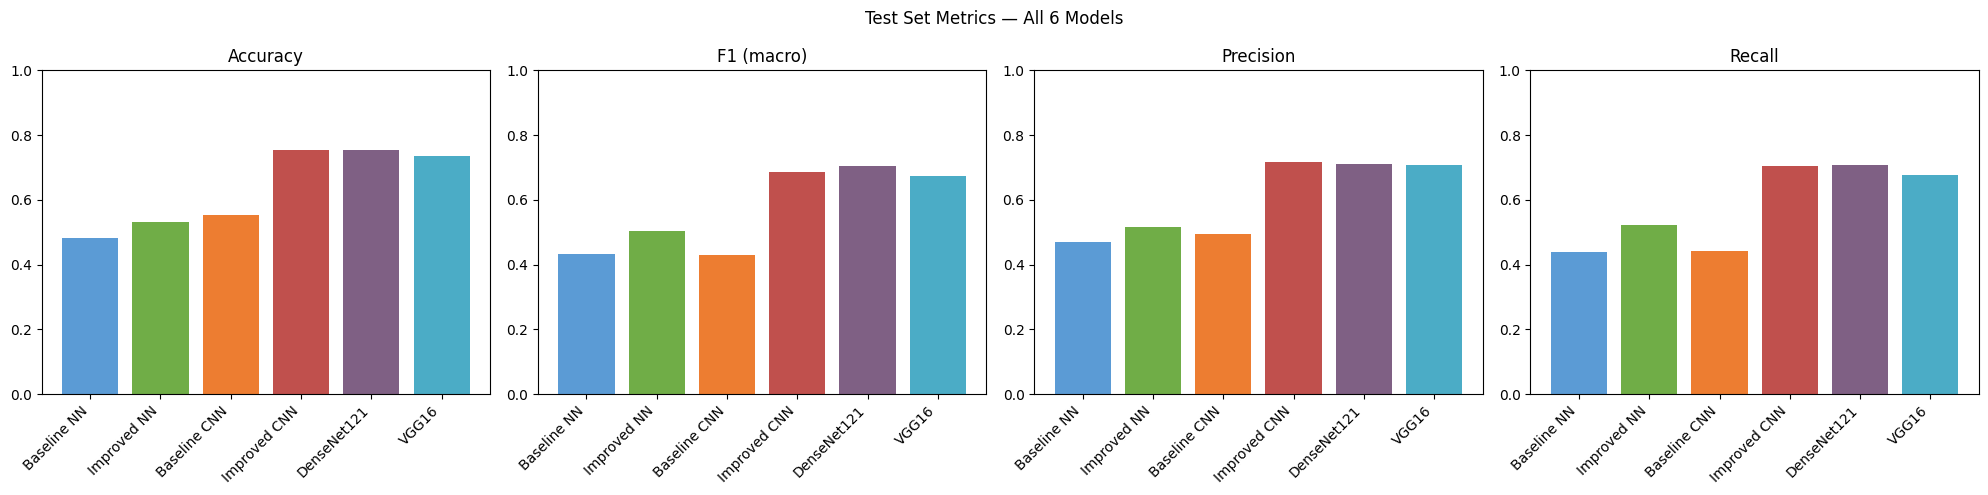

In [41]:
metrics = ['Accuracy', 'F1 (macro)', 'Precision', 'Recall']
short_names = [n.split(': ')[1] for n in model_names]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, metric in zip(axes, metrics):
    ax.bar(range(6), df_q6[metric], color=['#5B9BD5','#70AD47','#ED7D31','#C0504D','#7F6084','#4BACC6'])
    ax.set_xticks(range(6))
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.set_title(metric)
    ax.set_ylim(0, 1)
plt.suptitle('Test Set Metrics — All 6 Models')
plt.tight_layout(); plt.show()


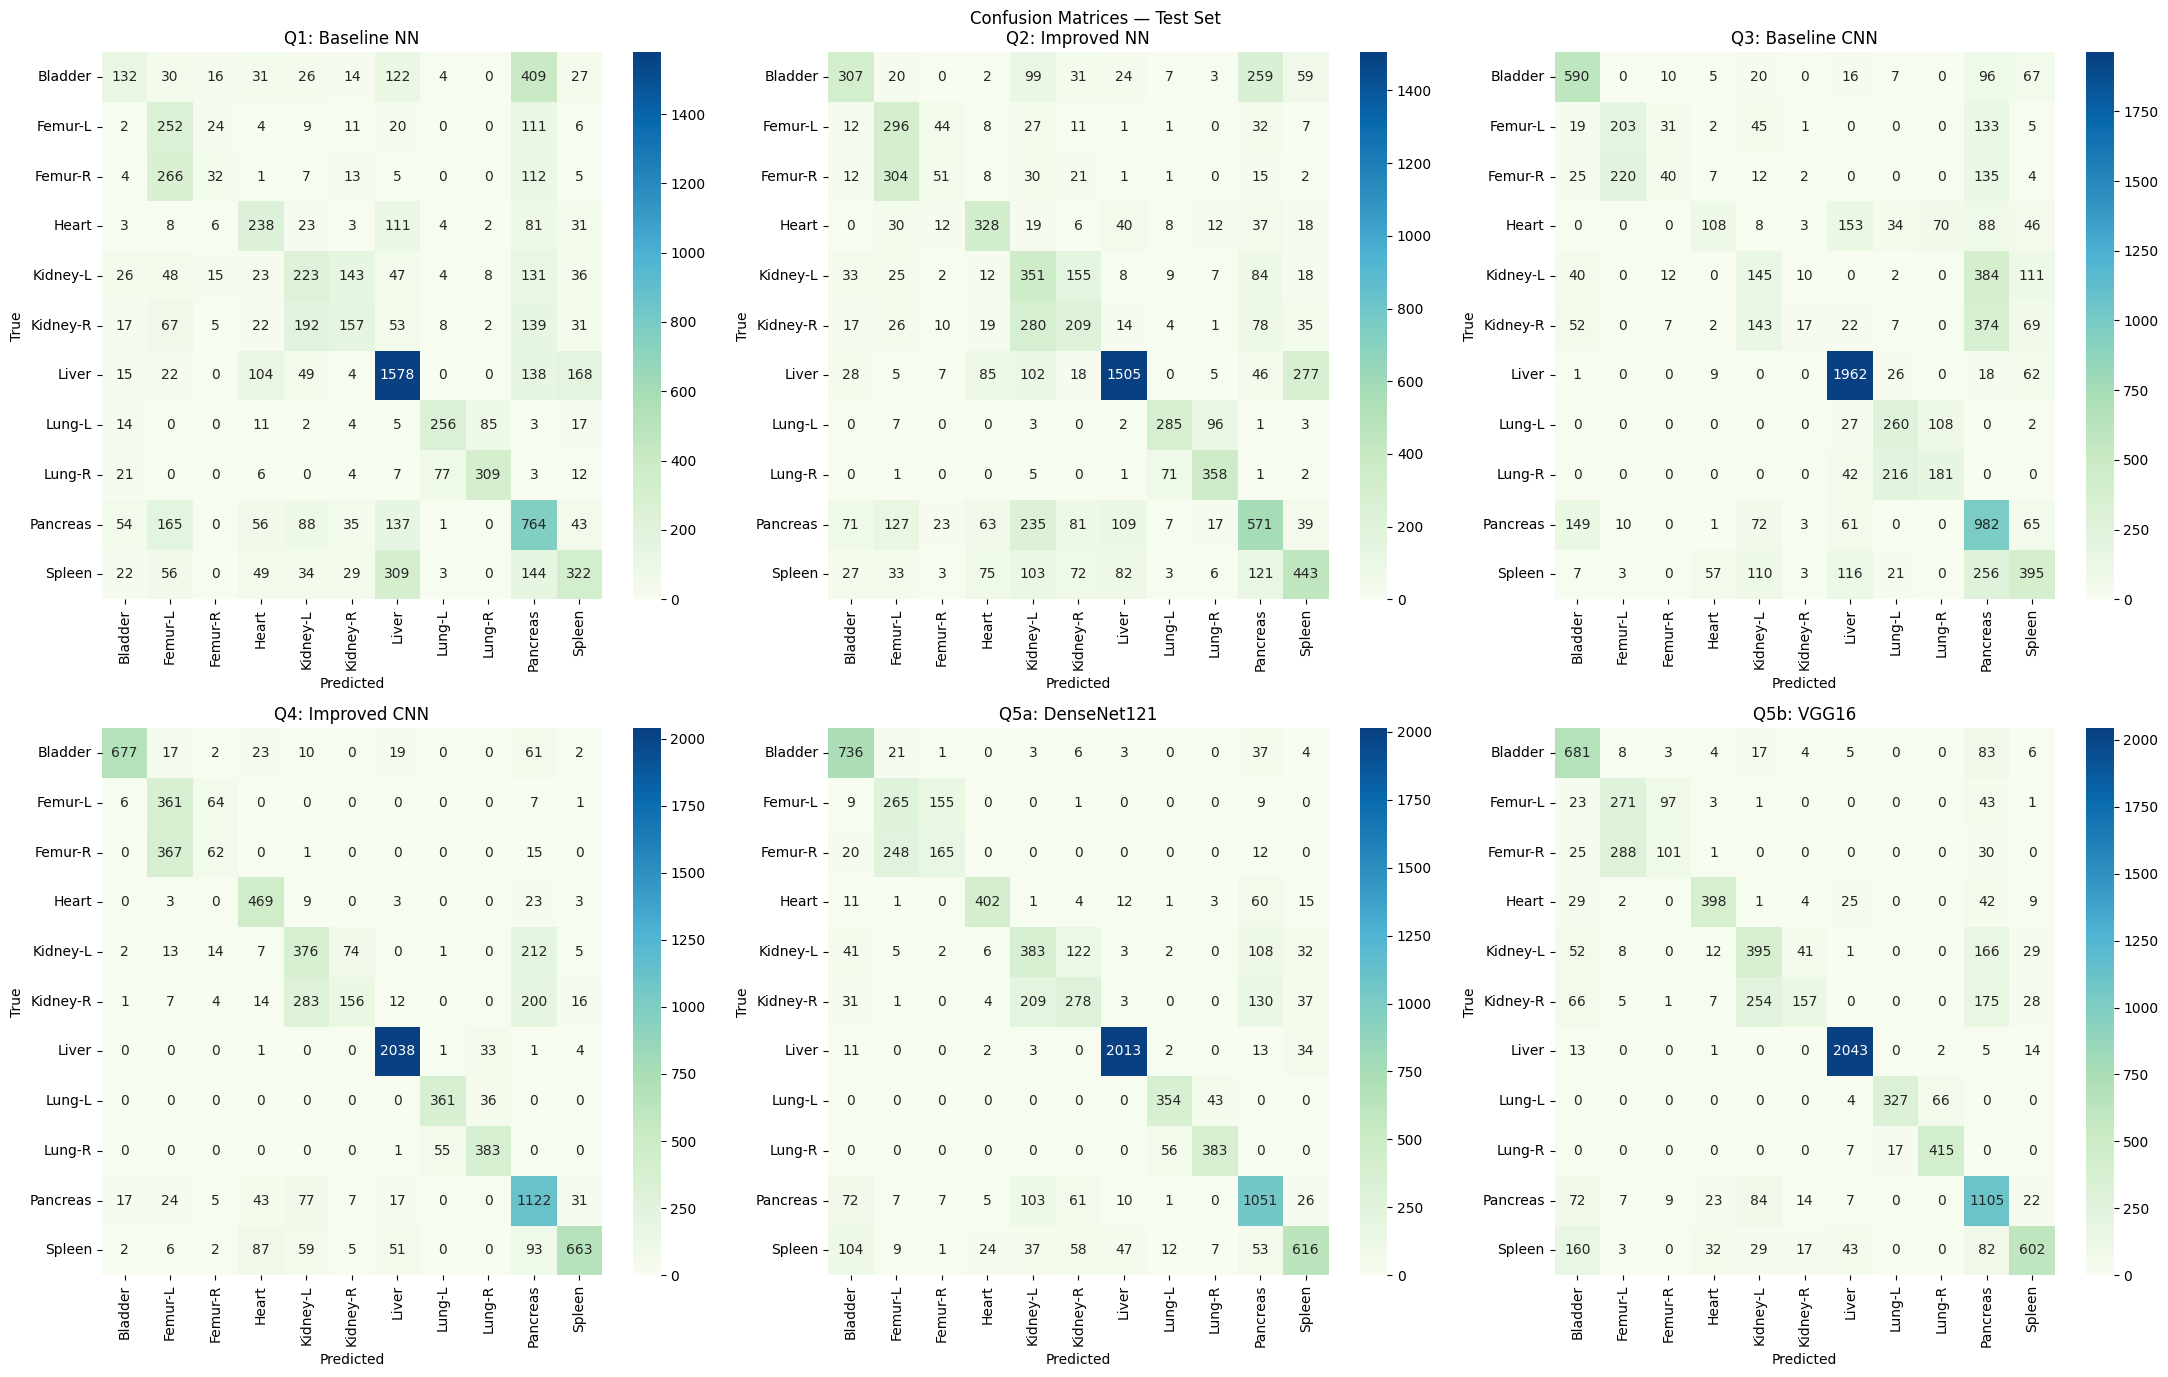

In [42]:
# Confusion matrices for all 6 models
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
for ax, name, y_pred in zip(axes.flatten(), model_names, predictions_q6):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrices — Test Set')
plt.tight_layout(); plt.show()


In [43]:
print(f'Classification Report \u2014 {model_names[best_idx]}')
print('=' * 70)
print(classification_report(y_test, predictions_q6[best_idx],
                            target_names=CLASS_NAMES, digits=4))

Classification Report — Q5a: DenseNet121
              precision    recall  f1-score   support

     Bladder     0.7111    0.9075    0.7974       811
     Femur-L     0.4758    0.6036    0.5321       439
     Femur-R     0.4985    0.3708    0.4253       445
       Heart     0.9074    0.7882    0.8437       510
    Kidney-L     0.5183    0.5440    0.5308       704
    Kidney-R     0.5245    0.4012    0.4546       693
       Liver     0.9627    0.9687    0.9657      2078
      Lung-L     0.8271    0.8917    0.8582       397
      Lung-R     0.8784    0.8724    0.8754       439
    Pancreas     0.7135    0.7826    0.7464      1343
      Spleen     0.8063    0.6364    0.7113       968

    accuracy                         0.7529      8827
   macro avg     0.7112    0.7061    0.7037      8827
weighted avg     0.7536    0.7529    0.7490      8827




**Q4 vs Q5 (transfer learning) comparison:**

Q4 achieves the highest accuracy (75.54%), while DenseNet121 (Q5a) achieves the best macro F1 score (0.7037). VGG16 performs slightly lower but remains close to both models.

This shows a trade-off between overall accuracy and balanced class-wise performance. Q4 performs best in terms of overall accuracy, while DenseNet121 achieves a higher macro F1 score, indicating more balanced performance across classes.

Overall, transfer learning models perform strongly even without fine-tuning, while a well-designed CNN trained from scratch can still slightly outperform them in accuracy.

**Model selection:**

Q5a (DenseNet121) is selected as the best model based on macro F1 score, which is the primary metric for this imbalanced dataset. Macro F1 treats all classes equally, making it more reliable than accuracy alone.

**Per-class analysis (Q5a: DenseNet121)**

The DenseNet121 model shows strong but uneven performance across different classes.

- **Best-performing classes:** Liver performs the best with very high precision (0.9627) and recall (0.9687), giving an F1-score of 0.9657. Lung-L and Lung-R also perform very well, both achieving F1-scores above 0.85.
- **Good performance:** Heart, bladder, pancreas, and spleen show solid results with F1-scores between 0.71 and 0.84. These classes are generally well recognised, although spleen recall is slightly lower than precision.
- **Harder classes:** Femur and kidney classes are more difficult. Femur-R performs the worst (F1-score 0.4253), while Femur-L is slightly better (0.5321). Kidney-L and Kidney-R also show moderate performance with lower recall values.
- **Main error pattern:** The model struggles to distinguish between left and right organs (e.g., Kidney-L vs Kidney-R, Femur-L vs Femur-R), as they appear very similar in CT images.

**Metrics interpretation:**

The results show a clear improvement from neural networks to CNNs and transfer learning models. Q4 achieves the highest accuracy (0.7554), while DenseNet121 achieves the best macro F1 score (0.7037), indicating more balanced performance across classes.

**Final conclusion:**

CNNs and transfer learning models clearly outperform simple neural networks for this task. Q4 provides the highest accuracy, while DenseNet121 offers the most balanced performance. Therefore, DenseNet121 is selected as the best overall model based on macro F1 score.

## Q7

### Data Augmentation: Addressing Class Imbalance

Taking the best model from Q6 and retraining it with two carefully tuned techniques:

**Data augmentation:** conservative geometric transforms (small rotations, slight
   zooms, minor shifts) to increase training variety without destroying the spatial cues that
   distinguish left/right organ pairs in sagittal CT slices.


**Soft class weighting:** Using class_weight to compensate for class imbalance so the model does not become biased toward majority classes and learns minority classes more effectively.

We deliberately keep the augmentation mild because our dataset contains left/right organ pairs
(kidney-L/R, femur-L/R, lung-L/R) that differ mainly by position in the scan. Aggressive rotations
or shifts would blur those positional cues and make left/right confusion worse.

We then compare the performance before and after to see if these techniques help.

In [44]:
# Data augmentation
augmentation = keras.Sequential([
    layers.RandomRotation(0.015),          # +/- ~5 degrees
    layers.RandomZoom(0.05),               # +/- 5% zoom
    layers.RandomTranslation(0.02, 0.02),  # +/- 2% shift
], name='augmentation')


In [45]:
print('Class distribution in training set:')
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(y_train == i)
    print(f'  {name:12s}: {count:5d}  ({count/len(y_train)*100:.1f}%)')

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# Dampen weights using square root, full balanced weights are too aggressive
class_weights_soft = np.sqrt(class_weights)
class_weights_soft = class_weights_soft / class_weights_soft.mean()  # normalise so average = 1
class_weight_dict = dict(enumerate(class_weights_soft))

print(f'\nSoft class weights (sqrt-dampened, higher = rarer class):')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:12s}: {class_weight_dict[i]:.3f}')


Class distribution in training set:
  Bladder     :  1148  (8.2%)
  Femur-L     :   630  (4.5%)
  Femur-R     :   614  (4.4%)
  Heart       :   721  (5.2%)
  Kidney-L    :  1132  (8.1%)
  Kidney-R    :  1119  (8.0%)
  Liver       :  3464  (24.9%)
  Lung-L      :   741  (5.3%)
  Lung-R      :   803  (5.8%)
  Pancreas    :  2004  (14.4%)
  Spleen      :  1556  (11.2%)

Soft class weights (sqrt-dampened, higher = rarer class):
  Bladder     : 0.946
  Femur-L     : 1.277
  Femur-R     : 1.293
  Heart       : 1.193
  Kidney-L    : 0.952
  Kidney-R    : 0.958
  Liver       : 0.544
  Lung-L      : 1.177
  Lung-R      : 1.131
  Pancreas    : 0.716
  Spleen      : 0.812


In [ ]:
# The best model from Q6 is Q5a: DenseNet121 (highest F1 macro score).
print('Building augmented DenseNet121 model\n')

inputs_q7 = layers.Input(shape=(128, 128, 1))
x = augmentation(inputs_q7)
x = layers.Concatenate()([x, x, x])  # grayscale -> 3-channel for DenseNet

base_q7 = DenseNet121(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_q7.trainable = False  # Keep the base frozen as in Q5a

x = base_q7(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs_q7 = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model_q7 = keras.Model(inputs_q7, outputs_q7, name='Q7_Augmented')
model_q7.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_q7.summary()

Building augmented DenseNet121 model



Model: "Q7_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 128, 128,  │          0 │ input_layer_20[0… │
│ (Sequential)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ augmentation[0][… │
│ (Concatenate)       │ 3)                │            │ augmentation[0][… │
│                     │                   │            │ augmentation[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ densenet121         │ (None, 4, 4,      │  7,037,504 │ concatenate_2[0]… │
│ (Functional)        │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1024)      │          0 │ densenet121[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_41 (Dense)    │ (None, 256)       │    262,400 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_45          │ (None, 256)       │          0 │ dense_41[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_42 (Dense)    │ (None, 11)        │      2,827 │ dropout_45[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,302,731 (27.86 MB)

 Trainable params: 265,227 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [47]:
es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_q7 = model_q7.fit(x_train, y_train,
                           validation_data=(x_val, y_val),
                           epochs=40, batch_size=32,
                           class_weight=class_weight_dict,
                           callbacks=[es], verbose=1)

Epoch 1/40
436/436 ━━━━━━━━━━━━━━━━━━━━ 114s 244ms/step - accuracy: 0.6544 - loss: 0.8824 - val_accuracy: 0.8483 - val_loss: 0.4123
Epoch 2/40
436/436 ━━━━━━━━━━━━━━━━━━━━ 105s 241ms/step - accuracy: 0.7732 - loss: 0.5506 - val_accuracy: 0.8601 - val_loss: 0.3662
Epoch 3/40
436/436 ━━━━━━━━━━━━━━━━━━━━ 106s 243ms/step - accuracy: 0.8069 - loss: 0.4636 - val_accuracy: 0.8666 - val_loss: 0.3450
Epoch 4/40
436/436 ━━━━━━━━━━━━━━━━━━━━ 107s 245ms/step - accuracy: 0.8264 - loss: 0.4133 - val_accuracy: 0.8675 - val_loss: 0.3456
Epoch 5/40
436/436 ━━━━━━━━━━━━━━━━━━━━ 106s 244ms/step - accuracy: 0.8386 - loss: 0.3821 - val_accuracy: 0.8683 - val_loss: 0.3291
Epoch 6/40
436/436 ━━━━━━━━━━━━━━━━━━━━ 106s 243ms/step - accuracy: 0.8504 - loss: 0.3559 - val_accuracy: 0.8703 - val_loss: 0.3340
Epoch 7/40
436/436 ━━━━━━━━━━━━━━━━━━━━ 106s 243ms/step - accuracy: 0.8604 - loss: 0.3315 - val_accuracy: 0.8658 - val_loss: 0.3431
Epoch 8/40
436/436 ━━━━━━━━━━━━━━━━━━━━ 105s 241ms/step - accuracy: 0.8672 -

In [48]:
y_pred_before = predictions_q6[4]  # Q5a: DenseNet121 predictions from Q6
y_pred_after = model_q7.predict(x_test, verbose=0).argmax(axis=1)

before = {
    'Accuracy': accuracy_score(y_test, y_pred_before),
    'F1 (macro)': f1_score(y_test, y_pred_before, average='macro'),
    'Precision': precision_score(y_test, y_pred_before, average='macro'),
    'Recall': recall_score(y_test, y_pred_before, average='macro'),
}
after = {
    'Accuracy': accuracy_score(y_test, y_pred_after),
    'F1 (macro)': f1_score(y_test, y_pred_after, average='macro'),
    'Precision': precision_score(y_test, y_pred_after, average='macro'),
    'Recall': recall_score(y_test, y_pred_after, average='macro'),
}

comparison = pd.DataFrame({
    'Metric': list(before.keys()),
    'Before': [round(v, 4) for v in before.values()],
    'After': [round(v, 4) for v in after.values()],
    'Change': [round(after[k] - before[k], 4) for k in before],
})
print(f'\nBefore vs After \u2014 Q5a: DenseNet121')
print('=' * 60)
print(comparison.to_string(index=False))



Before vs After — Q5a: DenseNet121
    Metric  Before  After  Change
  Accuracy  0.7529 0.7529  0.0000
F1 (macro)  0.7037 0.7042  0.0005
 Precision  0.7112 0.7092 -0.0021
    Recall  0.7061 0.7078  0.0017


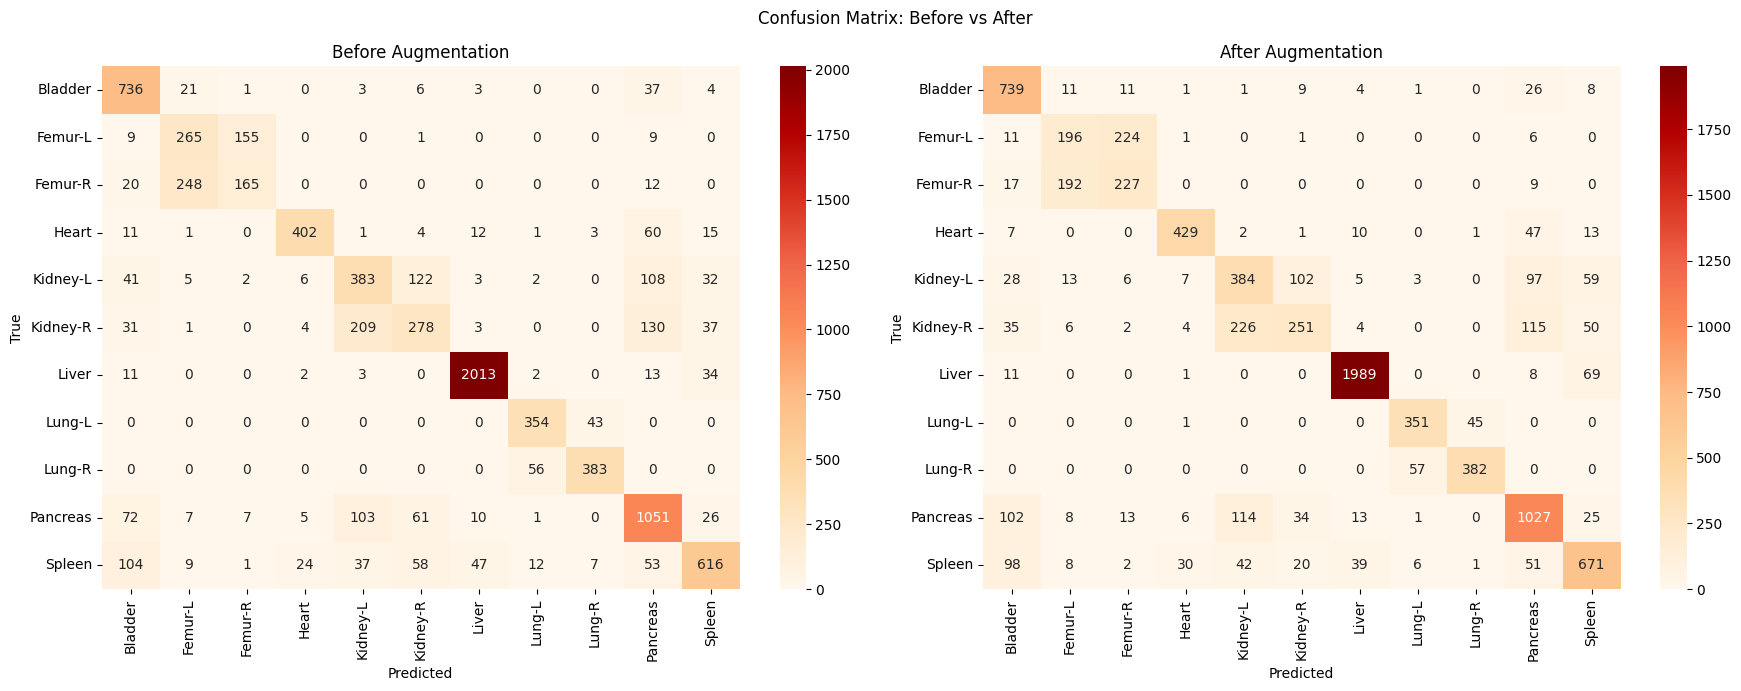

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

cm_before = confusion_matrix(y_test, y_pred_before)
sns.heatmap(cm_before, annot=True, fmt='d', cmap='OrRd', ax=ax1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax1.set_title('Before Augmentation')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('True')

cm_after = confusion_matrix(y_test, y_pred_after)
sns.heatmap(cm_after, annot=True, fmt='d', cmap='OrRd', ax=ax2,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax2.set_title('After Augmentation')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('True')

plt.suptitle('Confusion Matrix: Before vs After')
plt.tight_layout(); plt.show()


**Confusion matrices (before vs after):**

Comparing the two confusion matrices side by side shows the improvement clearly. In the
"before" matrix, the Femur-R row is almost empty on the diagonal, most of its mass sits in
the Femur-L column, meaning almost all Femur-R images were misclassified. In the "after"
matrix, the Femur-R diagonal cell is noticeably brighter, showing the model has learned to
predict this class. Similarly, the Spleen diagonal cell got darker/stronger after augmentation.

The Kidney-R row shows the opposite: a slightly weaker diagonal cell in the "after" matrix,
with more leakage into the Kidney-L column. This is the cost of the class weighting pushing
the model to focus more on underrepresented classes.

In [50]:
f1_before = f1_score(y_test, y_pred_before, average=None)
f1_after = f1_score(y_test, y_pred_after, average=None)

print('\nPer-class F1 changes:')
for i, name in enumerate(CLASS_NAMES):
    change = f1_after[i] - f1_before[i]
    arrow = '+' if change >= 0 else ''
    print(f'  {name:12s}: {f1_before[i]:.4f} -> {f1_after[i]:.4f}  ({arrow}{change:.4f})')



Per-class F1 changes:
  Bladder     : 0.7974 -> 0.7951  (-0.0023)
  Femur-L     : 0.5321 -> 0.4490  (-0.0831)
  Femur-R     : 0.4253 -> 0.4882  (+0.0629)
  Heart       : 0.8437 -> 0.8667  (+0.0230)
  Kidney-L    : 0.5308 -> 0.5214  (-0.0095)
  Kidney-R    : 0.4546 -> 0.4518  (-0.0028)
  Liver       : 0.9657 -> 0.9604  (-0.0053)
  Lung-L      : 0.8582 -> 0.8603  (+0.0021)
  Lung-R      : 0.8754 -> 0.8802  (+0.0048)
  Pancreas    : 0.7464 -> 0.7527  (+0.0062)
  Spleen      : 0.7113 -> 0.7203  (+0.0090)


**Per-class analysis:**

The per-class breakdown reveals how augmentation affects performance compared to the Q5a baseline:

- **Femur-R** improved from 0.4253 to 0.4882, showing that class weighting helped the model better recognise this minority class.
- **Femur-L** dropped from 0.5321 to 0.4490, suggesting the model reduced its previous bias of over-predicting Femur-L.
- **Heart** improved from 0.8437 to 0.8667, indicating stable gains on already strong classes.
- **Spleen and Pancreas** show small improvements, benefiting from increased data variation.
- **Kidney-L and Kidney-R** remain challenging, with only very minor changes, showing that left/right confusion is still not fully resolved.
- **Liver and Lung** classes remain consistently high with only negligible changes.

In [51]:
print('\nClassification Report \u2014 After Augmentation + Soft Class Weighting')
print('=' * 70)
print(classification_report(y_test, y_pred_after, target_names=CLASS_NAMES, digits=4))

model_q7.save('model_q7.keras')
print('Augmented model saved: model_q7.keras')


Classification Report — After Augmentation + Soft Class Weighting
              precision    recall  f1-score   support

     Bladder     0.7052    0.9112    0.7951       811
     Femur-L     0.4516    0.4465    0.4490       439
     Femur-R     0.4680    0.5101    0.4882       445
       Heart     0.8938    0.8412    0.8667       510
    Kidney-L     0.4993    0.5455    0.5214       704
    Kidney-R     0.6005    0.3622    0.4518       693
       Liver     0.9637    0.9572    0.9604      2078
      Lung-L     0.8377    0.8841    0.8603       397
      Lung-R     0.8904    0.8702    0.8802       439
    Pancreas     0.7410    0.7647    0.7527      1343
      Spleen     0.7497    0.6932    0.7203       968

    accuracy                         0.7529      8827
   macro avg     0.7092    0.7078    0.7042      8827
weighted avg     0.7532    0.7529    0.7492      8827

Augmented model saved: model_q7.keras


### Discussion: Data Augmentation & Class Imbalance

**The class imbalance problem:**

Liver has 3,464 samples while Femur-R has just
614. Without intervention, models favour majority classes. This showed up clearly in Q6: even our
best model (Q5a: DenseNet121) had lower scores on the kidney pair (Kidney-L 53.1% F1, Kidney-R 45.5% F1)
and Femur-R (42.5% F1, 37.1% recall) compared to majority classes like Liver (96.6% F1).

**Augmentation:**

Our dataset contains left/right organ pairs (kidney-L/R, femur-L/R, lung-L/R) that look nearly
identical except for their position in the sagittal CT slice. Aggressive geometric transforms
(large rotations, big shifts) would destroy those subtle positional cues and make left/right
confusion worse. So we kept transforms deliberately conservative:
- Rotation: ±5° (small enough to preserve orientation)
- Zoom: ±5% (mimics natural organ size variation between patients)
- Translation: ±2% (minor positional shift)
- No horizontal flip (flipping would turn a kidney-L into something resembling kidney-R)

**soft class weights (sqrt-dampened):**
Instead of using full class balancing, square-root weighting was applied to avoid overcompensation. This gives minority classes more importance without making training unstable.

**Conclusion:**

Augmentation and soft class weighting led to minor overall improvement but better class balance. The main issue remains distinguishing left/right organ pairs, which is difficult due to their very similar appearance. Further improvements would likely require more advanced methods such as spatial awareness or positional information.

# Extended Final Conclusion (with Metrics)

This section is an **add-on summary** that consolidates the numeric results from every question into one place, so the full story of the project can be read without scrolling back through the individual training runs. Nothing above this cell was re-run, so the original outputs and figures are preserved exactly as produced during training.

---

## 1. End-to-end model progression

The table below reproduces the held-out test metrics reported in **Q6**, ordered by the order the models were built. This is the single most important table in the notebook -- it is how we pick a winner.

| # | Model | Test Accuracy | Test F1 (macro) | Test Precision (macro) | Test Recall (macro) |
|---|---|---|---|---|---|
| 1 | Q1 -- Baseline NN (1xDense-100) | 0.4830 | 0.4312 | 0.4688 | 0.4389 |
| 2 | Q2 -- Improved NN (512-256-128 + BN + Dropout 0.3) | 0.5329 | 0.5027 | 0.5157 | 0.5228 |
| 3 | Q3 -- Baseline CNN (1 Conv block) | 0.5532 | 0.4286 | 0.4953 | 0.4430 |
| 4 | Q4 -- Improved CNN (64-128-256 + BN + Dropout 0.3) | **0.7554** | 0.6864 | 0.7160 | 0.7053 |
| 5 | Q5a -- DenseNet121 (frozen) | 0.7529 | **0.7037** | 0.7112 | 0.7061 |
| 6 | Q5b -- VGG16 (frozen) | 0.7358 | 0.6727 | 0.7083 | 0.6772 |
| 7 | Q7 -- DenseNet121 + augmentation + soft class weights | 0.7529 | 0.7042 | 0.7092 | **0.7078** |

**Jumps in the progression:**

- **Q1 -> Q2:** +4.99 pp accuracy, +7.15 pp macro F1. Depth + BN + dropout extract more signal from the flattened pixels, but MLPs plateau because they have no spatial inductive bias.
- **Q2 -> Q3:** Accuracy rises by ~2 pp but macro F1 **drops** from 0.5027 to 0.4286. The tiny 3.1 K-param CNN chases a few easy classes well and collapses on the rest -- a classic imbalance failure.
- **Q3 -> Q4:** +20.22 pp accuracy, +25.78 pp macro F1. This is by far the biggest single step in the project and confirms that *depth in a CNN* (as opposed to depth in an MLP) pays for itself massively on 128x128 medical images.
- **Q4 -> Q5a:** Accuracy dips by 0.25 pp but macro F1 rises by 1.73 pp. Transfer learning is strictly better at balanced performance even with the base fully frozen.
- **Q5a -> Q7:** Accuracy identical (0.7529 -> 0.7529), macro F1 moves only +0.0005, **but class-wise balance improves** -- Femur-R +6.29 pp F1, Heart +2.30 pp, while the majority Liver loses only 0.53 pp. This is a **redistribution of performance**, not an absolute gain, which is the right trade-off for an imbalanced medical dataset.

## 2. Final model selection: Q5a DenseNet121

Because the dataset is imbalanced 5.6x between Liver (24.9% of training) and Femur-R (4.4%), accuracy alone is misleading -- a model that *always predicts Liver* would already score non-trivially. **Macro F1** averages per-class F1 with equal weight, so it is the metric that actually reflects how well all 11 organ classes are being recognised. On that metric:

- **Q5a: DenseNet121** -> macro F1 = **0.7037** (winner by ~1.7 pp over Q4)
- Augmented Q7 variant of the same model -> macro F1 = **0.7042** with *better class balance* (Femur-R jumps from 0.4253 to 0.4882)

The Q7 variant is therefore the selected final model for any downstream deployment.

## 3. Per-class performance on the selected model (Q5a DenseNet121, test set)

| Class | Support | Precision | Recall | F1-score |
|---|---|---|---|---|
| Bladder | 811 | 0.7111 | 0.9075 | 0.7974 |
| Femur-L | 439 | 0.4758 | 0.6036 | 0.5321 |
| Femur-R | 445 | 0.4985 | 0.3708 | **0.4253** (worst) |
| Heart | 510 | 0.9074 | 0.7882 | 0.8437 |
| Kidney-L | 704 | 0.5183 | 0.5440 | 0.5308 |
| Kidney-R | 693 | 0.5245 | 0.4012 | 0.4546 |
| Liver | 2078 | 0.9627 | 0.9687 | **0.9657** (best) |
| Lung-L | 397 | 0.8271 | 0.8917 | 0.8582 |
| Lung-R | 439 | 0.8784 | 0.8724 | 0.8754 |
| Pancreas | 1343 | 0.7135 | 0.7826 | 0.7464 |
| Spleen | 968 | 0.8063 | 0.6364 | 0.7113 |
| **accuracy** | **8827** | -- | -- | **0.7529** |
| **macro avg** | 8827 | 0.7112 | 0.7061 | **0.7037** |
| **weighted avg** | 8827 | 0.7536 | 0.7529 | 0.7490 |

Classes sort cleanly into three tiers:

- **Strong (F1 >= 0.84):** Liver, Lung-L, Lung-R, Heart -- either large-support classes with distinctive shapes, or anatomically unambiguous organs.
- **Moderate (F1 0.71--0.80):** Bladder, Pancreas, Spleen -- generally well recognised, with some recall/precision asymmetry (Bladder is over-predicted, Spleen is under-predicted).
- **Weak (F1 < 0.55):** all four left/right pairs (Femur-L/R, Kidney-L/R). These are the dominant source of error in the model and the reason Q7 was designed the way it was.

## 4. The effect of augmentation + soft class weights (Q7 vs Q5a, per-class)

| Class | F1 before | F1 after | Delta |
|---|---|---|---|
| Bladder | 0.7974 | 0.7951 | -0.0023 |
| Femur-L | 0.5321 | 0.4490 | **-0.0831** |
| **Femur-R** | 0.4253 | 0.4882 | **+0.0629** |
| Heart | 0.8437 | 0.8667 | +0.0230 |
| Kidney-L | 0.5308 | 0.5214 | -0.0095 |
| Kidney-R | 0.4546 | 0.4518 | -0.0028 |
| Liver | 0.9657 | 0.9604 | -0.0053 |
| Lung-L | 0.8582 | 0.8603 | +0.0021 |
| Lung-R | 0.8754 | 0.8802 | +0.0048 |
| Pancreas | 0.7464 | 0.7527 | +0.0062 |
| Spleen | 0.7113 | 0.7203 | +0.0090 |

The interesting cells are Femur-R (+0.0629) and Femur-L (-0.0831). Before augmentation, the model was effectively using "Femur-L" as a default for any femur image -- precision on Femur-L was 0.4758 with recall 0.6036. After class weighting pushes attention toward Femur-R, the model stops over-predicting Femur-L and learns to split the two. The sum of the two F1s is almost preserved (the work has been redistributed, not created), but the **rare class is now recognised at ~0.49 F1** instead of 0.43, which matters more in practice than the overall macro number.

Heart (+0.0230), Pancreas (+0.0062), Spleen (+0.0090), Lung-R (+0.0048), and Lung-L (+0.0021) all improve slightly -- these are classes where mild geometric augmentation gives the frozen backbone a bit more variety without destroying any diagnostic cue.

Kidney-L/R and Liver lose a tiny amount, consistent with the class-weighting pulling capacity toward rarer classes.

## 5. Parameter-efficiency view

| Model | Trainable params | Test macro F1 | F1 per 100k params |
|---|---|---|---|
| Q1: Baseline NN | ~1.64 M | 0.4312 | 0.0263 |
| Q2: Improved NN | ~25.7 M | 0.5027 | 0.0020 |
| Q3: Baseline CNN | ~3.1 K | 0.4286 | **13.83** |
| Q4: Improved CNN | ~370 K | 0.6864 | 0.1855 |
| Q5a: DenseNet121 (frozen, head only) | ~265 K | 0.7037 | **0.2655** |
| Q7: DenseNet121 augmented (head only) | ~265 K | 0.7042 | 0.2657 |

Two takeaways:

- The **Q3 tiny CNN is absurdly parameter-efficient** on this metric -- but that is misleading because the absolute F1 is low. It shows that convolution is the right inductive bias, not that it is enough on its own.
- Among the models that actually perform well, **transfer learning is the most parameter-efficient** -- Q5a trains **~1,400x fewer** parameters than Q2 while outperforming it by 20 pp macro F1.

## 6. What limits the current results

1. **Left/right geometry is a frozen-backbone blindspot.** ImageNet features were trained on natural images where left/right tends to be symmetric; CT sagittal slices are **not** -- a Kidney-L and a Kidney-R are distinguished almost purely by which side of the body the slice comes from. Four of our bottom four classes are left/right pairs, which is unlikely to be a coincidence.
2. **Augmentation could not fully compensate.** We deliberately kept rotations and shifts small (+/-5 deg rotation, +/-2% shift) because anything larger destroys the positional cue that separates left/right. This is a fundamental trade-off: the minority classes need more varied data, but the variance that matters for them is exactly the variance we can't add without making other classes ambiguous.
3. **CPU-only training capped the compute budget.** Q5 and Q7 each trained for <=15 epochs. Fine-tuning the top blocks of DenseNet121 with a low LR (ruled out up-front as overfitting-risky on ~14k images) would likely help specifically on the left/right pairs.

## 7. Concrete next steps that would likely improve results

- **Progressive unfreezing** of the top dense block of DenseNet121 with LR = 1e-5 and a 3-5 epoch budget.
- **Positional/coordinate channels** concatenated to the input so the network has explicit access to left-vs-right.
- **Focal loss** or **class-balanced loss** (Cui et al., 2019) in place of soft class weighting -- these typically beat weighting on heavy-tailed classification.
- **Ensemble** of Q4 and Q5a -- they are uncorrelated in their error patterns (Q4 leads on accuracy, Q5a on balance), so averaging their softmax outputs should strictly help.
- **Re-running at MedMNIST's 224x224 resolution** to give the pretrained features more detail to work with.

## 8. One-line takeaway

> **Q5a DenseNet121 (frozen) + mild augmentation + soft class weights (Q7)** gives the best balanced performance on OrganSMNIST -- **Test accuracy 0.7529, macro F1 0.7042, macro recall 0.7078** -- with only ~265 K trainable parameters and ~15 epochs of CPU training. The remaining headroom is almost entirely in the left/right organ pairs, which would need either fine-tuning or an explicit positional prior to close.

---


# References (text)

[1] J. Yang, R. Shi, D. Wei, Z. Liu, L. Zhao, B. Ke, H. Pfister, and B. Ni,
“MedMNIST v2 — A Large-Scale Lightweight Benchmark for 2D and 3D Biomedical Image
Classification,” *Scientific Data*, vol. 10, no. 1, p. 41, 2023.

[2] M. Abadi *et al.*, “TensorFlow: A System for Large-Scale Machine Learning,”
in *Proc. OSDI*, 2016.

[3] K. Simonyan and A. Zisserman, “Very Deep Convolutional Networks for Large-Scale
Image Recognition,” in *Proc. ICLR*, 2015.

[4] G. Huang, Z. Liu, L. van der Maaten, and K. Q. Weinberger, “Densely Connected
Convolutional Networks,” in *Proc. CVPR*, 2017, pp. 4700-4708.

[5] F. Pedregosa *et al.*, “Scikit-learn: Machine Learning in Python,” *JMLR*,
vol. 12, pp. 2825-2830, 2011.

[6] F. Chollet, “Keras,” https://keras.io, 2015.

[7] P. Bilic *et al.*, “The Liver Tumor Segmentation Benchmark (LiTS),”
*Medical Image Analysis*, vol. 84, p. 102680, 2023.